PyTorch available!
Using device: cpu
Loading datasets...
Found 12409 images in /content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Train
Found 3111 images in /content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Validation
Found 3880 images in /content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Test
Train: 12409, Val: 3111, Test: 3880
Starting training...

Epoch 1/4
------------------------------
Batch 0/388, Loss: 2.3712
Batch 50/388, Loss: 0.9563
Batch 100/388, Loss: 0.5802
Batch 150/388, Loss: 0.2603
Batch 200/388, Loss: 0.5682
Batch 250/388, Loss: 0.3124
Batch 300/388, Loss: 0.4831
Batch 350/388, Loss: 0.4607
Train Loss: 0.5467, Train Acc: 82.05%
Val Loss: 0.1642, Val Acc: 94.86%

Epoch 2/4
------------------------------
Batch 0/388, Loss: 0.3260
Batch 50/388, Loss: 0.4842
Batch 100/388, Loss: 0.1564
Batch 150/388, Loss: 0.3796
Batch 200/388, Loss: 0.0887
Batch 250/388, Loss: 0.1603
Batch 300/388, Loss: 0.2691
Batch 350/388, Loss: 0.0869
Train Loss: 0.31

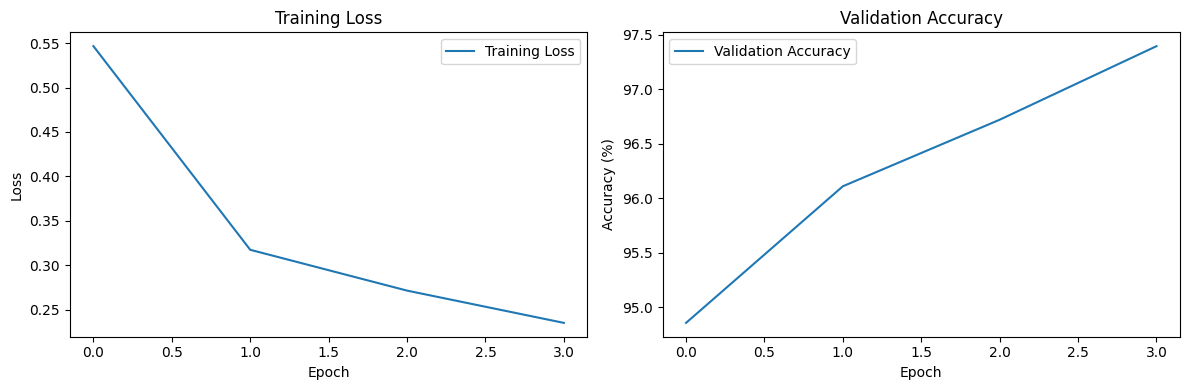

Best validation accuracy: 97.40%
Model saved as 'best_bengali_model.pth'


In [ ]:
# Minimal Bengali Digit Classification without complex dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Simple CNN using only basic libraries
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torchvision.transforms as transforms
    TORCH_AVAILABLE = True
    print("PyTorch available!")
except:
    TORCH_AVAILABLE = False
    print("PyTorch not available, will use alternative approach")

if TORCH_AVAILABLE:
    # Custom Dataset class to avoid torchvision.datasets dependency
    class BengaliDigitDataset(Dataset):
        def __init__(self, root_dir, transform=None):
            self.root_dir = root_dir
            self.transform = transform
            self.image_paths = []
            self.labels = []

            # Load all images and labels
            for digit in range(10):
                digit_dir = os.path.join(root_dir, str(digit))
                if os.path.exists(digit_dir):
                    for img_path in glob.glob(os.path.join(digit_dir, "*")):
                        if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                            self.image_paths.append(img_path)
                            self.labels.append(digit)

            print(f"Found {len(self.image_paths)} images in {root_dir}")

        def __len__(self):
            return len(self.image_paths)

        def __getitem__(self, idx):
            img_path = self.image_paths[idx]
            image = Image.open(img_path).convert('RGB')
            label = self.labels[idx]

            if self.transform:
                image = self.transform(image)

            return image, label

    # Simple CNN model
    class SimpleCNN(nn.Module):
        def __init__(self, num_classes=10):
            super(SimpleCNN, self).__init__()
            self.features = nn.Sequential(
                # First conv block
                nn.Conv2d(3, 32, 3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),

                # Second conv block
                nn.Conv2d(32, 64, 3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),

                # Third conv block
                nn.Conv2d(64, 128, 3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),

                # Fourth conv block
                nn.Conv2d(128, 256, 3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((4, 4))
            )

            self.classifier = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(256 * 4 * 4, 512),
                nn.ReLU(inplace=True),
                nn.Dropout(0.5),
                nn.Linear(512, num_classes)
            )

        def forward(self, x):
            x = self.features(x)
            x = x.view(x.size(0), -1)
            x = self.classifier(x)
            return x

    # Configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Paths - CHANGE THESE TO YOUR DATASET PATHS
    train_dir = "/content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Train"
    val_dir = "/content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Validation"
    test_dir = "/content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Test"

    # Hyperparameters
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 4
    IMG_SIZE = 128  # Smaller for faster training

    # Data transforms
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create datasets and dataloaders
    print("Loading datasets...")
    try:
        train_dataset = BengaliDigitDataset(train_dir, transform=train_transform)
        val_dataset = BengaliDigitDataset(val_dir, transform=val_transform)
        test_dataset = BengaliDigitDataset(test_dir, transform=val_transform)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

        print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

        # Create model
        model = SimpleCNN(num_classes=10).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

        # Training function
        def train_epoch(model, loader, criterion, optimizer, device):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for batch_idx, (data, target) in enumerate(loader):
                data, target = data.to(device), target.to(device)

                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()

                if batch_idx % 50 == 0:
                    print(f'Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}')

            return running_loss / len(loader), 100. * correct / total

        # Validation function
        def validate(model, loader, criterion, device):
            model.eval()
            val_loss = 0
            correct = 0
            total = 0

            with torch.no_grad():
                for data, target in loader:
                    data, target = data.to(device), target.to(device)
                    output = model(data)
                    val_loss += criterion(output, target).item()
                    _, predicted = output.max(1)
                    total += target.size(0)
                    correct += predicted.eq(target).sum().item()

            return val_loss / len(loader), 100. * correct / total

        # Training loop
        print("Starting training...")
        train_losses = []
        val_accuracies = []
        best_val_acc = 0

        for epoch in range(EPOCHS):
            print(f'\nEpoch {epoch+1}/{EPOCHS}')
            print('-' * 30)

            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = validate(model, val_loader, criterion, device)

            train_losses.append(train_loss)
            val_accuracies.append(val_acc)

            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), 'best_bengali_model.pth')

        # Test evaluation
        test_loss, test_acc = validate(model, test_loader, criterion, device)
        print(f'\nTest Accuracy: {test_acc:.2f}%')

        # Plot results
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Training Loss')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(val_accuracies, label='Validation Accuracy')
        plt.title('Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()

        plt.tight_layout()
        plt.savefig('training_progress.png')
        plt.show()

        print(f"Best validation accuracy: {best_val_acc:.2f}%")
        print("Model saved as 'best_bengali_model.pth'")

    except FileNotFoundError as e:
        print(f"Dataset directory not found: {e}")
        print("Please update the dataset paths in the code")
        print("Expected structure:")
        print("dataset/")
        print("├── train/")
        print("│   ├── 0/")
        print("│   ├── 1/")
        print("│   └── ...")
        print("├── validation/")
        print("└── test/")

else:
    print("PyTorch not available. Please fix the installation first.")
    print("\nTry these commands:")
    print("pip uninstall torch torchvision")
    print("pip install torch torchvision")

Using device: cpu
Found 12409 images in /content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Train
Found 3111 images in /content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Validation
Found 3880 images in /content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Test
Train: 12409, Val: 3111, Test: 3880
Starting training...

Epoch 1/4
------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Batch 0/388, Loss: 2.4571
Batch 50/388, Loss: 0.3875
Batch 100/388, Loss: 0.1037
Batch 150/388, Loss: 0.6801
Batch 200/388, Loss: 0.3258
Batch 250/388, Loss: 0.2629
Batch 300/388, Loss: 0.0802
Batch 350/388, Loss: 0.0948
Train Loss: 0.3343, Train Acc: 88.98%
Val Loss: 0.1266, Val Acc: 95.72%

Epoch 2/4
------------------------------
Batch 0/388, Loss: 0.1194
Batch 50/388, Loss: 0.1746
Batch 100/388, Loss: 0.4303
Batch 150/388, Loss: 0.0407
Batch 200/388, Loss: 0.0486
Batch 250/388, Loss: 0.0407
Batch 300/388, Loss: 0.1470
Batch 350/388, Loss: 0.2284
Train Loss: 0.1389, Train Acc: 95.80%
Val Loss: 0.0971, Val Acc: 97.11%

Epoch 3/4
------------------------------
Batch 0/388, Loss: 0.2848
Batch 50/388, Loss: 0.0763
Batch 100/388, Loss: 0.1072
Batch 150/388, Loss: 0.3320
Batch 200/388, Loss: 0.0368
Batch 250/388, Loss: 0.0113
Batch 300/388, Loss: 0.0389
Batch 350/388, Loss: 0.0371
Train Loss: 0.1119, Train Acc: 96.77%
Val Loss: 0.0715, Val Acc: 98.07%

Epoch 4/4
--------------------------

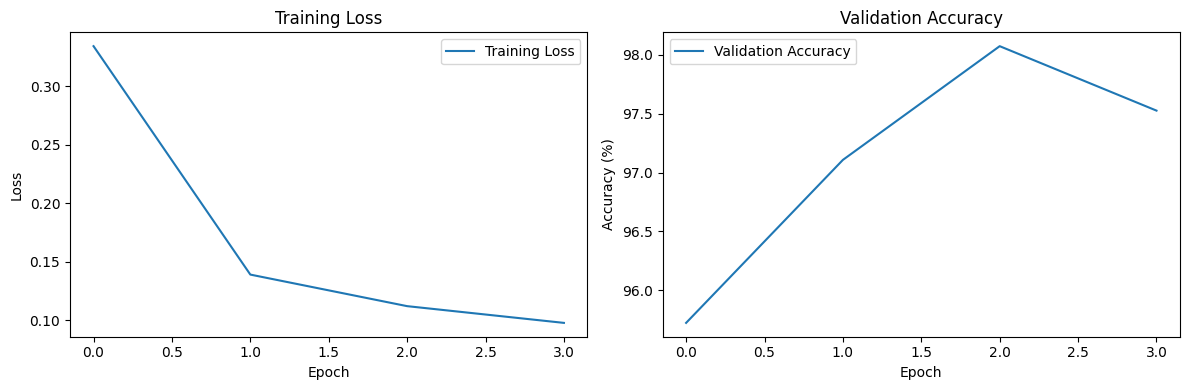

Best validation accuracy: 98.07%
Model saved as 'best_bengali_resnet18.pth'


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# -------------------------------
# Dataset Class
# -------------------------------
class BengaliDigitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for digit in range(10):
            digit_dir = os.path.join(root_dir, str(digit))
            if os.path.exists(digit_dir):
                for img_path in glob.glob(os.path.join(digit_dir, "*")):
                    if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(img_path)
                        self.labels.append(digit)

        print(f"Found {len(self.image_paths)} images in {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# -------------------------------
# Configuration
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dir = "/content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Train"
val_dir = "/content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Validation"
test_dir = "/content/drive/MyDrive/Data_BanglaLekha_Train_Test_Validation/Test"

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 4
IMG_SIZE = 128

# -------------------------------
# Data transforms
# -------------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------------
# Datasets & Dataloaders
# -------------------------------
train_dataset = BengaliDigitDataset(train_dir, transform=train_transform)
val_dataset = BengaliDigitDataset(val_dir, transform=val_transform)
test_dataset = BengaliDigitDataset(test_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# -------------------------------
# ResNet-18 Model
# -------------------------------
model = models.resnet18(pretrained=False)   # pretrained=True if you want ImageNet weights
# Replace final fully connected layer for 10 classes
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# -------------------------------
# Training & Validation Functions
# -------------------------------
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()

        if batch_idx % 50 == 0:
            print(f'Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}')

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    return val_loss / len(loader), 100. * correct / total

# -------------------------------
# Training Loop
# -------------------------------
print("Starting training...")
train_losses, val_accuracies = [], []
best_val_acc = 0

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('-' * 30)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_bengali_resnet18.pth')

# -------------------------------
# Test Evaluation
# -------------------------------
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f'\nTest Accuracy: {test_acc:.2f}%')

# -------------------------------
# Plot Results
# -------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('training_progress_resnet18.png')
plt.show()

print(f"Best validation accuracy: {best_val_acc:.2f}%")
print("Model saved as 'best_bengali_resnet18.pth'")


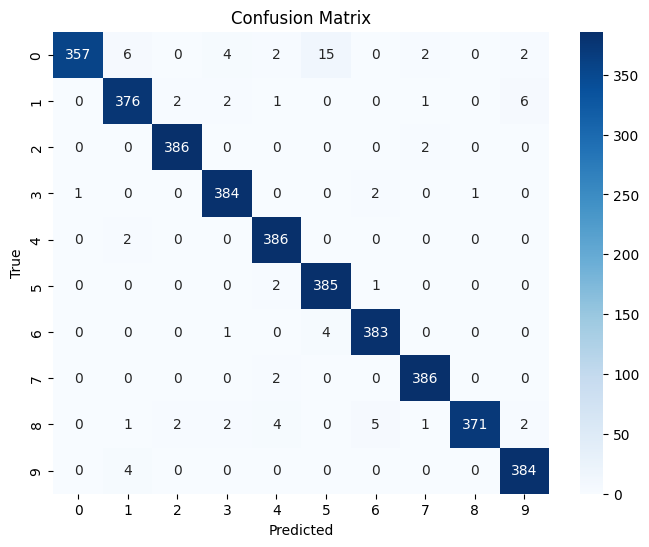

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, device, class_names=None):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# Example usage after training:
plot_confusion_matrix(model, test_loader, device, class_names=[str(i) for i in range(10)])


In [ ]:
from sklearn.metrics import classification_report

def print_classification_report(model, loader, device, class_names=None):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)

# Example usage:
print_classification_report(model, test_loader, device, class_names=[str(i) for i in range(10)])


              precision    recall  f1-score   support

           0       1.00      0.92      0.96       388
           1       0.97      0.97      0.97       388
           2       0.99      0.99      0.99       388
           3       0.98      0.99      0.98       388
           4       0.97      0.99      0.98       388
           5       0.95      0.99      0.97       388
           6       0.98      0.99      0.98       388
           7       0.98      0.99      0.99       388
           8       1.00      0.96      0.98       388
           9       0.97      0.99      0.98       388

    accuracy                           0.98      3880
   macro avg       0.98      0.98      0.98      3880
weighted avg       0.98      0.98      0.98      3880



In [ ]:
import numpy as np

def per_class_accuracy(model, loader, device, num_classes=10):
    model.eval()
    class_correct = [0] * num_classes
    class_total = [0] * num_classes

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, preds = torch.max(outputs, 1)
            c = (preds == target).squeeze()

            for i in range(len(target)):
                label = target[i].item()
                class_correct[label] += c[i].item()
                class_total[label] += 1

    for i in range(num_classes):
        if class_total[i] > 0:
            print(f"Digit {i}: {100 * class_correct[i] / class_total[i]:.2f}% accuracy")


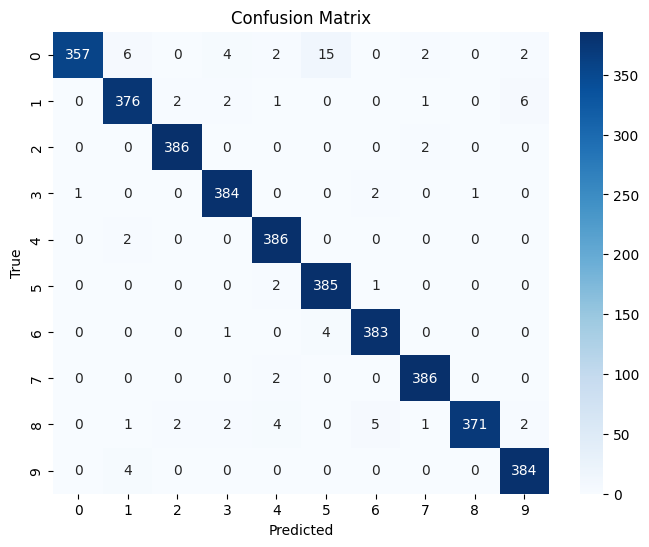

              precision    recall  f1-score   support

           0       1.00      0.92      0.96       388
           1       0.97      0.97      0.97       388
           2       0.99      0.99      0.99       388
           3       0.98      0.99      0.98       388
           4       0.97      0.99      0.98       388
           5       0.95      0.99      0.97       388
           6       0.98      0.99      0.98       388
           7       0.98      0.99      0.99       388
           8       1.00      0.96      0.98       388
           9       0.97      0.99      0.98       388

    accuracy                           0.98      3880
   macro avg       0.98      0.98      0.98      3880
weighted avg       0.98      0.98      0.98      3880

Digit 0: 92.01% accuracy
Digit 1: 96.91% accuracy
Digit 2: 99.48% accuracy
Digit 3: 98.97% accuracy
Digit 4: 99.48% accuracy
Digit 5: 99.23% accuracy
Digit 6: 98.71% accuracy
Digit 7: 99.48% accuracy
Digit 8: 95.62% accuracy
Digit 9: 98.97% 

In [ ]:
plot_confusion_matrix(model, test_loader, device, class_names=[str(i) for i in range(10)])
print_classification_report(model, test_loader, device, class_names=[str(i) for i in range(10)])
per_class_accuracy(model, test_loader, device)
